# Л1 — Підготовка даних

Велика частина роботи в Data Science — збір і підготовка даних. Саме тут виникає багато неочікуваних проблем і пасток.

Ноутбук нижче базово показує, як працювати з даними й готувати їх. Він не охоплює всіх можливих сценаріїв, а приклади в ньому часом сильно спрощені. Проте він дасть розуміння, де шукати помилки і як з ними боротися. Більше туторіалів — у [Kaggle Learn](https://www.kaggle.com/learn), зокрема [Data Cleaning](https://www.kaggle.com/learn/data-cleaning).

Базовий алгоритм підготовки даних може виглядати так (у дужках — кроки цього ноутбука):

- зчитування даних і початкове дослідження (1);
- дослідження структури й особливостей даних, зміна типів (2);
- об'єднання даних з різних джерел (3–4);
- робота з пропущеними й зламаними значеннями: drop, fill тощо (5, 7, 8);
- пошук outliers: drop, clip тощо (6);
- пошук зайвих і бракуючих колонок (9).

І головне: з кожною дією треба бути обережним. Outliers можуть бути реальними даними, які логічно пояснюються і які не можна видаляти. А пропущені значення можуть щось означати й бути корисними. Обидва випадки є в цій роботі.

Далі бувають кроки, специфічні для певних моделей чи алгоритмів:

- scaling: normalization, standardization тощо;
- обробка категорійних колонок: one-hot encoding тощо;
- dimensionality reduction.

Тут вони не розглядаються, частину з них побачите в Л2 і Л3.

Шаблон веде покроково: у кожному кроці — навіщо він і що зробити, у клітинці з `TODO` — ваш код. Опис даних і таблиця недоліків — у `README.md`.

In [42]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

## 1. Завантаження даних

На цьому етапі важливо впевнитися, що файли завантажено правильно, і подивитися, що взагалі всередині. Можуть допомогти `df.head()`, `df.tail()`, `df.shape` і `df.dtypes`.

Що ви маєте зрозуміти?

- Чи зчиталися дані взагалі?
- Чи правильно розпарсилися рядки, колонки й значення?
- Які типи в колонок?
- Які приблизно значення?
- Скільки рядків і колонок?

In [43]:
df_meters = pd.read_parquet("meters.parquet")
df_registry = pd.read_csv("registry.csv")

print("meters:", df_meters.shape)
print("registry:", df_registry.shape)

print("\nТипи meters:")
print(df_meters.dtypes)

print("\nТипи registry:")
print(df_registry.dtypes)

print("\nПерші рядки meters:")
display(df_meters.head())

print("\nПерші рядки registry:")
display(df_registry.head())

meters: (526169, 4)
registry: (800, 7)

Типи meters:
meter_id                      str
ts                 datetime64[us]
consumption_kwh           float64
record_ts          datetime64[us]
dtype: object

Типи registry:
meter_id              str
customer_type         str
tariff                str
electric_heating    int64
connection_year     int64
years_connected     int64
district              str
dtype: object

Перші рядки meters:


,meter_id,ts,consumption_kwh,record_ts
0,UA100900,2026-01-05 00:00:00,0.1257,2026-01-05 00:01:52
1,UA100900,2026-01-05 01:00:00,0.1173,2026-01-05 01:06:56
2,UA100900,2026-01-05 02:00:00,0.1415,2026-01-05 02:14:19
3,UA100900,2026-01-05 03:00:00,0.1401,2026-01-05 03:03:01
4,UA100900,2026-01-05 04:00:00,0.1149,2026-01-05 04:13:02



Перші рядки registry:


,meter_id,customer_type,tariff,electric_heating,connection_year,years_connected,district
0,UA100900,household,single,0,2006,20,Solomianka
1,UA101907,small_business,dual_zone,0,2001,25,Obolon
2,UA102894,household,single,0,2008,17,Sviatoshyn
3,UA103276,household,single,0,1998,27,Solomianka
4,UA104249,household,dual_zone,1,1988,37,Obolon


## 2. Звірка з описом

Іноді бізнес надає опис ідеальних даних, але реальні дані часто з ним не збігаються. Тому спершу подивіться, чи ваші дані відповідають опису в `README.md`. Може допомогти `df.describe()`.

Перевірте (але поки не виправляйте):

- типи колонок: якщо число прочиталося як текст, частина операцій спрацює неправильно;
- скільки рядків мають `customer_type`, `tariff` чи `electric_heating`, яких немає в описі;
- скільки рядків мають `ts`, `connection_year` чи `years_connected` поза межами з опису;
- скільки різних лічильників у кожному файлі — мають бути по 800.

Можуть допомогти `isin`, `between` і `nunique`.

Недоліки з таблиці в `README.md` перевірятимете далі, кожен у своєму кроці. Межі споживання залежать від типу абонента, а тип є лише в реєстрі, тому їх перевірите після об'єднання, на кроці 6.

In [44]:
print("Опис числових колонок registry:")
print(df_registry.describe(), "\n")

# Допустимі категорії
allowed_types = ["household", "small_business", "industrial"]
allowed_tariffs = ["single", "dual_zone"]

print(
    "customer_type поза описом:",
    (~df_registry["customer_type"].isin(allowed_types)).sum()
)

print(
    "tariff поза описом:",
    (~df_registry["tariff"].isin(allowed_tariffs)).sum()
)

print(
    "electric_heating поза описом:",
    (~df_registry["electric_heating"].isin([0, 1])).sum()
)

# Допустимий часовий діапазон
valid_ts = df_meters["ts"].between(
    pd.Timestamp("2026-01-05 00:00"),
    pd.Timestamp("2026-02-01 23:00")
)

print("ts поза межами:", (~valid_ts).sum())

print(
    "connection_year поза межами:",
    (~df_registry["connection_year"].between(1985, 2024)).sum()
)

print(
    "years_connected поза межами:",
    (~df_registry["years_connected"].between(1, 41)).sum()
)

# Кількість різних лічильників
print("Лічильників у meters:", df_meters["meter_id"].nunique())
print("Лічильників у registry:", df_registry["meter_id"].nunique())

Опис числових колонок registry:
       electric_heating  connection_year  years_connected
count         800.00000       800.000000       800.000000
mean            0.20000      2003.765000        21.746250
std             0.40025        11.508816        11.530744
min             0.00000      1985.000000         1.000000
25%             0.00000      1994.000000        11.000000
50%             0.00000      2003.000000        22.000000
75%             0.00000      2014.000000        31.000000
max             1.00000      2024.000000        41.000000 

customer_type поза описом: 0
tariff поза описом: 0
electric_heating поза описом: 0
ts поза межами: 0
connection_year поза межами: 0
years_connected поза межами: 0
Лічильників у meters: 800
Лічильників у registry: 800


## 3. Реєстр: номери й райони (D-E, D-F)

Дані зберігаються в різних системах, тому формат ідентифікатора може не збігатися: `" UA123456"` для pandas — інший номер, ніж `UA123456`. Наївний join призведе до того, що частина даних втратиться. Так само `podil` і `Podil` — різні райони, і будь-який підрахунок по районах буде хибним.

Для D-E і D-F виведіть, скільки рядків реєстру зіпсовано, і виправте їх так, як сказано в таблиці недоліків. Можуть допомогти `str.fullmatch(r"UA\d{6}")`, `isin`, `str.strip()`, `str.lstrip("0")` і `str.capitalize()`.

In [45]:
# D-E: перевіряємо формат ідентифікаторів
invalid_ids = ~df_registry["meter_id"].str.fullmatch(r"UA\d{6}")

print("Кількість некоректних meter_id:", invalid_ids.sum())
print("Приклади:", df_registry.loc[invalid_ids, "meter_id"].head().to_list())

# Нормалізація ідентифікаторів
df_registry["meter_id"] = (
    df_registry["meter_id"]
    .str.strip()
    .str.lstrip("0")
)

check_ids = ~df_registry["meter_id"].str.fullmatch(r"UA\d{6}")
print("Некоректних meter_id після обробки:", check_ids.sum())


# D-F: перевіряємо назви районів
valid_districts = [
    "Podil",
    "Solomianka",
    "Darnytsia",
    "Obolon",
    "Sviatoshyn"
]

invalid_districts = ~df_registry["district"].isin(valid_districts)

print("\nКількість некоректних районів:", invalid_districts.sum())
print("Приклади:", df_registry.loc[invalid_districts, "district"].unique()[:10])

# Приводимо назви районів до єдиного формату
df_registry["district"] = (
    df_registry["district"]
    .str.strip()
    .str.capitalize()
)

district_check = ~df_registry["district"].isin(valid_districts)
print("Некоректних районів після обробки:", district_check.sum())

Кількість некоректних meter_id: 0
Приклади: []
Некоректних meter_id після обробки: 0

Кількість некоректних районів: 80
Приклади: <ArrowStringArray>
[     'Podil ',  'SVIATOSHYN',     'Obolon ',       'PODIL',   'darnytsia',
      'obolon', 'Sviatoshyn ',       'podil',  'solomianka',   'DARNYTSIA']
Length: 10, dtype: str
Некоректних районів після обробки: 0


## 4. Об'єднання

Тепер погодинні дані можна об'єднати з реєстром за `meter_id` (join, у pandas — `merge`). pandas не попереджає, коли рядок не знайшов пари, тому якість об'єднання треба перевірити самому.

Об'єднану таблицю назвіть `df`, з нею працюватимете далі. Перевірте й виведіть:

- кількість рядків до і після об'єднання — вона не має змінитися;
- кількість рядків без атрибутів абонента (пропуск у `customer_type`) — має бути 0.

Може допомогти `merge(..., how="left", validate="m:1")`: `validate` ще й перевірить, що кожному лічильнику відповідає один рядок реєстру.

In [46]:
# Кількість рядків до об'єднання
rows_before = len(df_meters)

# Об'єднуємо погодинні дані з реєстром
df = df_meters.merge(
    df_registry,
    how="left",
    on="meter_id",
    validate="m:1"
)

# Перевіряємо результат об'єднання
rows_after = len(df)
missing_customers = df["customer_type"].isna().sum()

print("Рядків до об'єднання:", rows_before)
print("Рядків після об'єднання:", rows_after)
print("Рядків без даних абонента:", missing_customers)

print("Кількість рядків не змінилася:", rows_before == rows_after)

df.head()

Рядків до об'єднання: 526169
Рядків після об'єднання: 526169
Рядків без даних абонента: 0
Кількість рядків не змінилася: True


,meter_id,ts,consumption_kwh,record_ts,customer_type,tariff,electric_heating,connection_year,years_connected,district
0,UA100900,2026-01-05 00:00:00,0.1257,2026-01-05 00:01:52,household,single,0,2006,20,Solomianka
1,UA100900,2026-01-05 01:00:00,0.1173,2026-01-05 01:06:56,household,single,0,2006,20,Solomianka
2,UA100900,2026-01-05 02:00:00,0.1415,2026-01-05 02:14:19,household,single,0,2006,20,Solomianka
3,UA100900,2026-01-05 03:00:00,0.1401,2026-01-05 03:03:01,household,single,0,2006,20,Solomianka
4,UA100900,2026-01-05 04:00:00,0.1149,2026-01-05 04:13:02,household,single,0,2006,20,Solomianka


## 5. Повторні відправки (D-C)

Повторна відправка — та сама година того самого лічильника ще раз, іноді з уточненим значенням. Якщо лишити обидва записи, споживання за цю годину подвоїться. Лишаємо найпізніший за `record_ts` запис як найсвіжіший.

Виведіть кількість рядків і кількість різних пар `meter_id` і `ts`, потім зніміть повтори. Можуть допомогти `duplicated(["meter_id", "ts"])`, `sort_values("record_ts")` і `drop_duplicates(["meter_id", "ts"], keep="last")`.

In [47]:
# D-C: перевіряємо повторні записи
total_rows = len(df)
unique_pairs = df[["meter_id", "ts"]].drop_duplicates().shape[0]

print("Загальна кількість рядків:", total_rows)
print("Кількість різних пар meter_id + ts:", unique_pairs)
print("Кількість повторних рядків:", total_rows - unique_pairs)

# Сортуємо за часом отримання запису
# Для кожної пари залишаємо найсвіжіший запис
df = (
    df.sort_values("record_ts")
      .drop_duplicates(["meter_id", "ts"], keep="last")
)

print("Рядків після видалення повторів:", len(df))

Загальна кількість рядків: 526169
Кількість різних пар meter_id + ts: 515964
Кількість повторних рядків: 10205
Рядків після видалення повторів: 515964


## 6. Одиниці виміру (D-D)

Значення у Вт·год схожі на викиди, але це не шум, а помилка одиниць. Якщо їх видалити, зникнуть цілі абоненти.

1. Для кожного лічильника порахуйте відношення його медіани `consumption_kwh` до медіани всіх рядків його `customer_type`. Більше 100 — лічильник звітує у Вт·год.
2. Побудуйте графік медіан лічильників за `customer_type` з логарифмічною віссю, наприклад boxplot.
3. Виведіть кількість лічильників у Вт·год, найбільше відношення серед решти лічильників і найменше серед лічильників у Вт·год (якщо таких немає — лише найбільше відношення серед усіх). Ці числа — доказ у звіті: вони показують, наскільки далеко від порога обидві групи.
4. Поділіть значення цих лічильників на 1000 і виведіть, скільки рядків поза межами споживання з опису, — має бути 0.

Можуть допомогти `DataFrame.boxplot(column=..., by="customer_type")`, `plt.yscale("log")` і `between`. Клітинку з діленням не запускайте двічі: значення поділяться ще раз. Якщо так сталося, перезапустіть ноутбук з початку.

Лічильників з неправильними одиницями: 64
Найбільше відношення серед нормальних: 5.29
Найменше відношення серед лічильників у Вт·год: 236.46


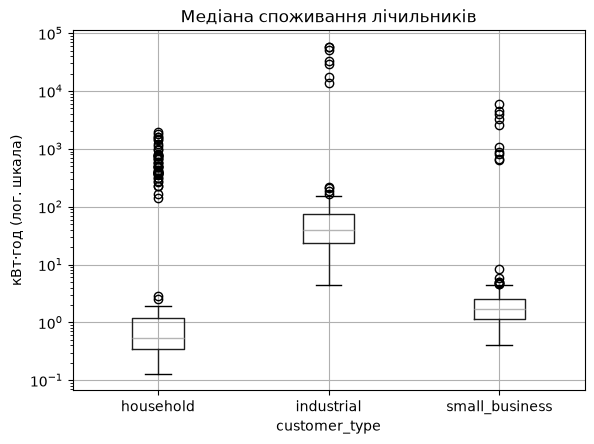

Рядків поза допустимими межами: 0


In [48]:
# D-D: визначаємо лічильники з неправильними одиницями

# Медіана споживання для кожного лічильника
meter_median = df.groupby("meter_id")["consumption_kwh"].median()

# Тип абонента для кожного лічильника
meter_type = df.groupby("meter_id")["customer_type"].first()

# Медіана споживання для кожного типу абонента
type_median = df.groupby("customer_type")["consumption_kwh"].median()

# Відношення медіани лічильника до медіани його типу
ratio = meter_median / meter_type.map(type_median)

# Лічильники, у яких значення у Вт·год
wrong_units = ratio > 100

print("Лічильників з неправильними одиницями:", wrong_units.sum())

# Докази біля порога 100
if wrong_units.any():
    max_normal = ratio[~wrong_units].max()
    min_wrong = ratio[wrong_units].min()

    print("Найбільше відношення серед нормальних:", round(max_normal, 2))
    print("Найменше відношення серед лічильників у Вт·год:", round(min_wrong, 2))
else:
    print("Найбільше відношення серед усіх:", round(ratio.max(), 2))

# Графік медіан лічильників за типом абонента
medians = pd.DataFrame({"median_kwh": meter_median, "customer_type": meter_type})
medians.boxplot(column="median_kwh", by="customer_type")
plt.yscale("log")
plt.title("Медіана споживання лічильників")
plt.suptitle("")
plt.ylabel("кВт·год (лог. шкала)")
plt.show()

# Виправляємо значення лічильників, які були у Вт·год
wrong_meter_ids = ratio[wrong_units].index

df.loc[
    df["meter_id"].isin(wrong_meter_ids),
    "consumption_kwh"
] /= 1000

# Перевірка меж споживання після виправлення
min_kwh = {
    "household": 0.01,
    "small_business": 0.02,
    "industrial": 1
}

max_kwh = {
    "household": 10,
    "small_business": 60,
    "industrial": 1200
}

outside_limits = ~df["consumption_kwh"].between(
    df["customer_type"].map(min_kwh),
    df["customer_type"].map(max_kwh)
)

print("Рядків поза допустимими межами:", outside_limits.sum())

## 7. Лічильники, що замовкли (D-A)

Пропуски не заповнюємо: те, що лічильник замовк, уже є інформацією про можливу відмову, а середнє її стерло б. Не видаляємо теж: до відмови лічильник передавав правильні дані.

Для кожного лічильника порахуйте, скільки годин минуло від його останнього `ts` до `2026-02-01 23:00`; більше 48 — замовк. Як на кроці 6, виведіть кількість замовклих, найбільшу тишу серед решти й найменшу серед замовклих (якщо замовклих немає — лише найбільшу тишу серед усіх).

Номери замовклих лічильників збережіть списком `silent`, наприклад `list(....index)`: він знадобиться в регресії.

Можуть допомогти `pd.Timestamp("2026-02-01 23:00")` і `/ pd.Timedelta(hours=1)`.

In [49]:
# D-A: визначаємо лічильники, які перестали передавати дані

end_ts = pd.Timestamp("2026-02-01 23:00")

# Останній час вимірювання для кожного лічильника
last_ts = df.groupby("meter_id")["ts"].max()

# Скільки годин минуло від останнього запису до кінця періоду
silence_hours = (end_ts - last_ts) / pd.Timedelta(hours=1)

# Лічильники, які мовчать більше 48 годин
silent = list(silence_hours[silence_hours > 48].index)

print("D-A: лічильників, що замовкли:", len(silent))

# Значення біля порога 48 годин
if len(silent) > 0:
    print(
        "Найбільша тиша серед решти:",
        round(silence_hours.drop(index=silent).max(), 2)
    )
    print(
        "Найменша тиша серед замовклих:",
        round(silence_hours.loc[silent].min(), 2)
    )
else:
    print(
        "Найбільша тиша серед усіх:",
        round(silence_hours.max(), 2)
    )

D-A: лічильників, що замовкли: 48
Найбільша тиша серед решти: 1.0
Найменша тиша серед замовклих: 155.0


## 8. Завмерлі лічильники (D-B)

Завмерлі значення виглядають правдоподібно, і ні середнє, ні максимум їх не видають. Помітно лише те, що значення перестали змінюватися. Такі лічильники не видаляємо: частина їхніх годин справна.

Для кожного лічильника порахуйте частку різних значень `consumption_kwh` серед його записів; менше 0.65 — завмер. Побудуйте гістограму цієї частки по лічильниках. Як на кроці 6, виведіть кількість завмерлих, найменшу частку серед решти й найбільшу серед завмерлих (якщо завмерлих немає — лише найменшу частку серед усіх).

Номери завмерлих лічильників збережіть списком `frozen`: він знадобиться в регресії.

Можуть допомогти `nunique()`, `size()` і `plt.hist`.

Завмерлих лічильників: 40
Найменша частка серед решти: 0.842
Найбільша частка серед завмерлих: 0.487


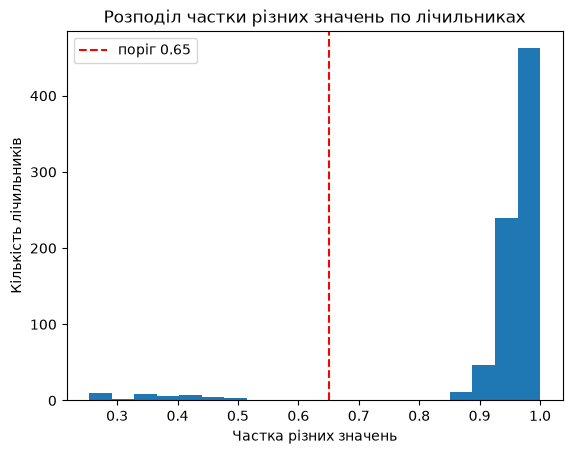

In [53]:
# D-B: визначаємо завмерлі лічильники

# Кількість різних значень для кожного лічильника
unique_values = df.groupby("meter_id")["consumption_kwh"].nunique()

# Загальна кількість записів для кожного лічильника
total_values = df.groupby("meter_id")["consumption_kwh"].size()

# Частка різних значень
distinct_share = unique_values / total_values

# Лічильники, у яких частка менша за 0.65
frozen = list(distinct_share[distinct_share < 0.65].index)

print("Завмерлих лічильників:", len(frozen))

# Значення біля порога 0.65
if len(frozen) > 0:
    print(
        "Найменша частка серед решти:",
        round(distinct_share.drop(index=frozen).min(), 3)
    )
    print(
        "Найбільша частка серед завмерлих:",
        round(distinct_share.loc[frozen].max(), 3)
    )
else:
    print(
        "Найменша частка серед усіх:",
        round(distinct_share.min(), 3)
    )

# Гістограма частки різних значень
plt.hist(distinct_share, bins=20)
plt.axvline(0.65, color="red", linestyle="--", label="поріг 0.65")

plt.xlabel("Частка різних значень")
plt.ylabel("Кількість лічильників")
plt.title("Розподіл частки різних значень по лічильниках")
plt.legend()
plt.show()

## 9. Кореляції

Колонка, що майже копіює іншу, не додає інформації: у кластеризації вона подвоює вагу того самого фактора, а в регресії робить коефіцієнти нестабільними. Технічна колонка `record_ts` після кроку 5 теж не потрібна.

Порахуйте кореляції між числовими колонками об'єднаної таблиці. Пару з кореляцією за модулем понад 0.95 вважайте копією і лиште з неї одну колонку. Приберіть `record_ts`. Підсумкову таблицю назвіть `result`.

Можуть допомогти `select_dtypes("number").corr().abs()` і `drop(columns=...)`.

In [54]:
# Dосліджуємо кореляції між числовими колонками
corr_matrix = df.select_dtypes("number").corr().abs()

# Знаходимо пари колонок з дуже високою кореляцією
copy_pairs = []

for col1 in corr_matrix.columns:
    for col2 in corr_matrix.columns:
        if col1 < col2 and corr_matrix.loc[col1, col2] > 0.95:
            copy_pairs.append(
                (col1, col2, corr_matrix.loc[col1, col2])
            )

print("Колонки з кореляцією понад 0.95:")
for col1, col2, corr_value in copy_pairs:
    print(f"{col1} — {col2}: {corr_value:.4f}")

# Визначаємо колонки, які потрібно прибрати
columns_to_remove = [pair[1] for pair in copy_pairs]

print("\nКолонки для видалення:", columns_to_remove)

# Формуємо підсумкову таблицю
result = df.drop(
    columns=columns_to_remove + ["record_ts"]
)

print("\nКолонки після очищення:")
print(result.columns.tolist())
print("Розмір result:", result.shape)

Колонки з кореляцією понад 0.95:
connection_year — years_connected: 0.9991

Колонки для видалення: ['years_connected']

Колонки після очищення:
['meter_id', 'ts', 'consumption_kwh', 'customer_type', 'tariff', 'electric_heating', 'connection_year', 'district']
Розмір result: (515964, 8)


## 10. Самоперевірка й збереження

Якщо якась перевірка падає, поверніться до відповідного кроку.

In [55]:
districts = ["Podil", "Solomianka", "Darnytsia", "Obolon", "Sviatoshyn"]
min_kwh = {"household": 0.01, "small_business": 0.02, "industrial": 1}
max_kwh = {"household": 10, "small_business": 60, "industrial": 1200}
corr = result.select_dtypes("number").corr().abs()
copies = [(a, b) for a in corr for b in corr if a < b and corr.loc[a, b] > 0.95]

assert not result.duplicated(["meter_id", "ts"]).any(), "лишилися повтори лічильник–година"
assert result["meter_id"].nunique() == 800, "лічильників має бути 800"
assert result["meter_id"].str.fullmatch(r"UA\d{6}").all(), "є номери не у форматі UA і 6 цифр"
assert result["customer_type"].notna().all(), "є рядки без атрибутів абонента"
assert result["district"].isin(districts).all(), "є райони, яких немає в описі"
assert result["consumption_kwh"].between(result["customer_type"].map(min_kwh), result["customer_type"].map(max_kwh)).all(), "є споживання поза межами з опису"
assert not copies, f"лишилися колонки-копії: {copies}"
assert "record_ts" not in result, "технічна колонка record_ts лишилася"

result.to_parquet("cleaned.parquet", index=False)
print("усе гаразд:", result.shape)

усе гаразд: (515964, 8)


## 11. Регресія

Регресію часто використовують, щоб передбачати певні показники. Проте лінійна регресія також показує, як кожен показник впливає на результат. Це і є регресійний аналіз.

Для прикладу подивимося, як на добове споживання домогосподарства впливають електроопалення і двозонний тариф: `y = a + b₁·x₁ + b₂·x₂`.

- `y` — середнє споживання лічильника за добу, кВт·год;
- `x₁` — `electric_heating`, `x₂` — двозонний тариф (обидва 0 або 1);
- `b₁` і `b₂` — на скільки кВт·год на добу більше споживає абонент із цим фактором за однакового іншого;
- `a` — споживання без опалення на звичайному тарифі;
- R² — яку частку розкиду споживання пояснюють обидва фактори, від 0 до 1.

Регресія тут краща за просте порівняння середніх: двозонний тариф здебільшого мають будинки з опаленням, і різниця середніх за тарифом приписала б тарифу ще й споживання на опалення.

Нормалізація не потрібна: обидва фактори мають однаковий масштаб (0 або 1), тож `b₁` і `b₂` можна порівнювати напряму, а `y` лишається в кВт·год на добу, і коефіцієнти легко пояснити. Якби фактори мали різні одиниці, наприклад площу і рік, для порівняння впливу їх спершу стандартизували б.

Лічильники з `silent` і `frozen` не беремо: у `cleaned.parquet` вони лишаються, але їхнє середнє споживання спотворене.

Код майже готовий: допишіть `homes` і запустіть.

In [56]:
# TODO: homes — рядки result для домогосподарств без лічильників із silent і frozen
# кожну умову беріть у дужки: result[(умова 1) & ~(умова 2)]
homes = result[
    (result["customer_type"] == "household")
    & (~result["meter_id"].isin(silent))
    & (~result["meter_id"].isin(frozen))
]

per_meter = homes.groupby("meter_id").agg(
    kwh_per_day=("consumption_kwh", "mean"),
    electric_heating=("electric_heating", "first"),
    tariff=("tariff", "first"),
)
per_meter["kwh_per_day"] *= 24
per_meter["dual_zone"] = (per_meter["tariff"] == "dual_zone").astype(int)

x, y = per_meter[["electric_heating", "dual_zone"]], per_meter["kwh_per_day"]
model = LinearRegression().fit(x, y)
print("лічильників:", len(per_meter))
print(f"a = {model.intercept_:.2f}, b₁ (опалення) = {model.coef_[0]:.2f}, b₂ (двозонний тариф) = {model.coef_[1]:.2f}, R² = {model.score(x, y):.3f}")

лічильників: 469
a = 10.71, b₁ (опалення) = 19.35, b₂ (двозонний тариф) = 3.13, R² = 0.702
